<a href="https://colab.research.google.com/github/elifnurerdemir/Transformer-Customer-Service-Sentiment-Analysis/blob/main/DI725_HW1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Customer Service Sentiment Analysis with Transformer**

**Section 0:** Setup and Data Loading

In [1]:
#Libaries
!pip install -q transformers datasets wandb accelerate

import pandas as pd
import wandb
import os

In [2]:

# Weights & Biases Initialization
wandb.login()
wandb.init(project="transformer-sentiment-analysis-di725", entity="elifnurerdemir")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: elifnurerdemir to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [4]:
#Data Loading
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')
print("Datasets loaded successfully!")
print(f"Training samples: {len(train_df)}")
print(f"Testing samples: {len(test_df)}")

Datasets loaded successfully!
Training samples: 970
Testing samples: 30


****Section 1:** Exploratory Data Analysis for the dataset**

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import CountVectorizer

# Visualization settings
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

In [6]:
# Load the dataset
df = pd.read_csv('train.csv')

# Standardize sentiment labels to lowercase
df['customer_sentiment'] = df['customer_sentiment'].str.lower()

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (970, 11)


,issue_area,issue_category,issue_sub_category,issue_category_sub_category,customer_sentiment,product_category,product_sub_category,issue_complexity,agent_experience_level,agent_experience_level_desc,conversation
0,Login and Account,Mobile Number and Email Verification,Verification requirement for mobile number or ...,Mobile Number and Email Verification -> Verifi...,neutral,Appliances,Oven Toaster Grills (OTG),medium,junior,"handles customer inquiries independently, poss...",Agent: Thank you for calling BrownBox Customer...
1,Cancellations and returns,Pickup and Shipping,Reasons for being asked to ship the item,Pickup and Shipping -> Reasons for being asked...,neutral,Electronics,Computer Monitor,less,junior,"handles customer inquiries independently, poss...",Agent: Thank you for calling BrownBox customer...
2,Cancellations and returns,Replacement and Return Process,Inability to click the 'Cancel' button,Replacement and Return Process -> Inability to...,neutral,Appliances,Juicer/Mixer/Grinder,medium,experienced,"confidently handles complex customer issues, e...",Agent: Thank you for calling BrownBox Customer...
3,Login and Account,Login Issues and Error Messages,Error message regarding exceeded attempts to e...,Login Issues and Error Messages -> Error messa...,neutral,Appliances,Water Purifier,less,inexperienced,"may struggle with ambiguous queries, rely on c...","Customer: Hi, I am facing an issue while loggi..."
4,Order,Order Delivery Issues,Delivery not attempted again,Order Delivery Issues -> Delivery not attempte...,negative,Electronics,Bp Monitor,medium,experienced,"confidently handles complex customer issues, e...",Agent: Thank you for contacting BrownBox custo...


--- Label Counts ---
customer_sentiment
neutral     542
negative    411
positive     17
Name: count, dtype: int64

--- Label Percentages ---
customer_sentiment
neutral     55.876289
negative    42.371134
positive     1.752577
Name: proportion, dtype: float64


/tmp/ipykernel_2920/2567469341.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='customer_sentiment', data=df, palette='viridis')


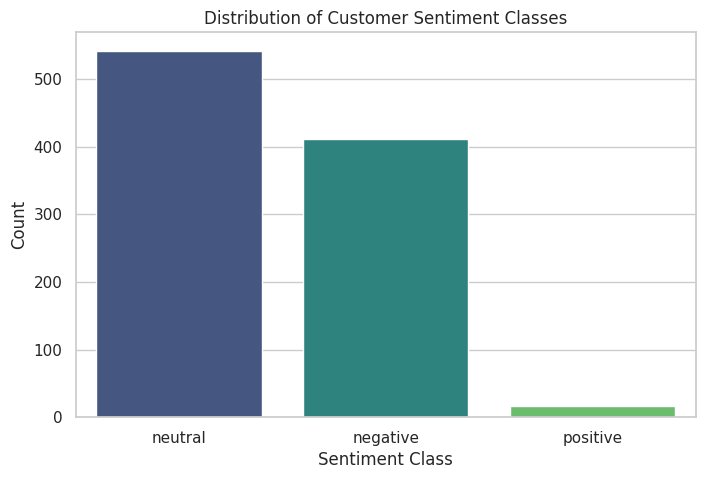

In [7]:
# Print the exact number of labels for each class
print("--- Label Counts ---")
label_counts = df['customer_sentiment'].value_counts()
print(label_counts)

# Calculate percentages
print("\n--- Label Percentages ---")
print(df['customer_sentiment'].value_counts(normalize=True) * 100)

# Visualization
plt.figure(figsize=(8, 5))
sns.countplot(x='customer_sentiment', data=df, palette='viridis')
plt.title('Distribution of Customer Sentiment Classes')
plt.xlabel('Sentiment Class')
plt.ylabel('Count')
plt.show()

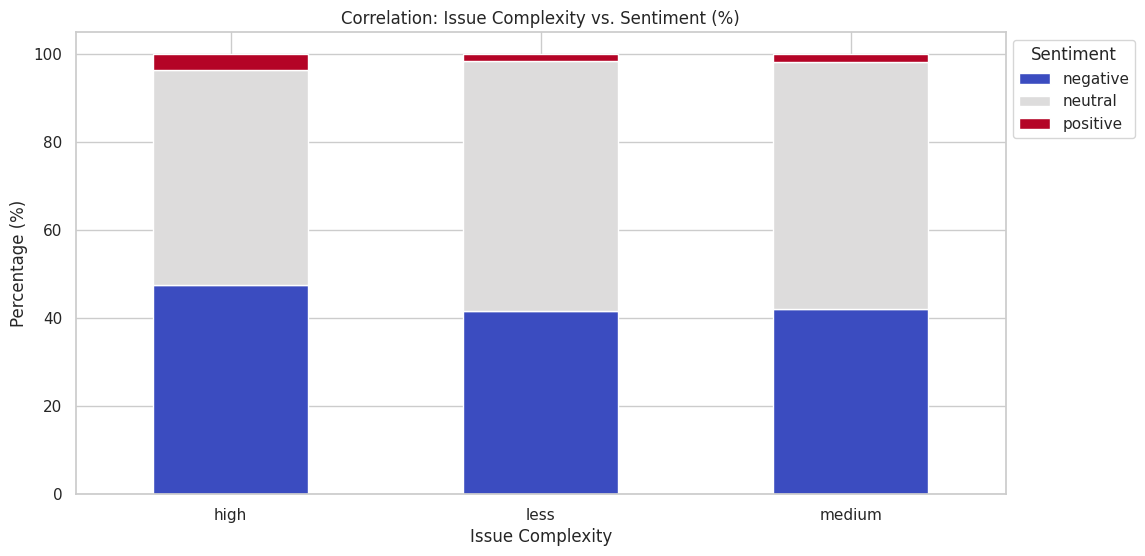

In [8]:
# Analyzing correlation between Issue Complexity and Sentiment
complexity_sentiment = pd.crosstab(df['issue_complexity'], df['customer_sentiment'], normalize='index') * 100

complexity_sentiment.plot(kind='bar', stacked=True, colormap='coolwarm')
plt.title('Correlation: Issue Complexity vs. Sentiment (%)')
plt.ylabel('Percentage (%)')
plt.xlabel('Issue Complexity')
plt.legend(title='Sentiment', bbox_to_anchor=(1, 1))
plt.xticks(rotation=0)
plt.show()

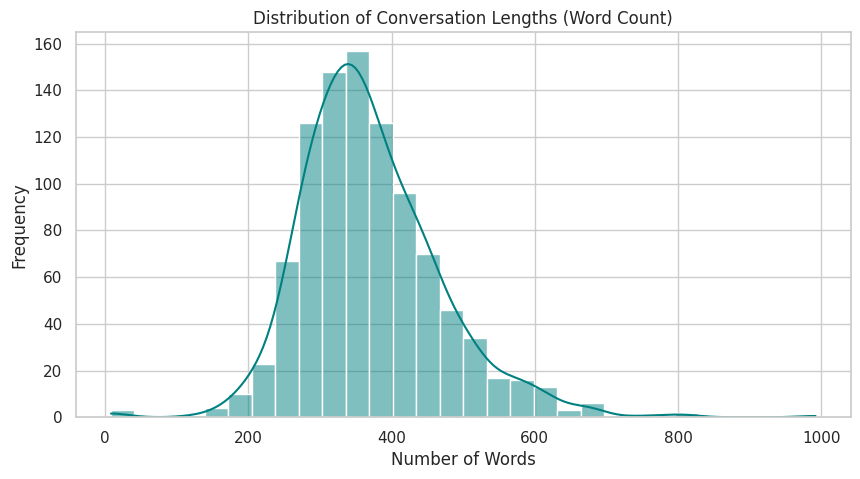

Average Word Count: 370.86
90th Percentile: 494.10


In [9]:
# Word count for each interaction
df['word_count'] = df['conversation'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 5))
sns.histplot(df['word_count'], bins=30, kde=True, color='teal')
plt.title('Distribution of Conversation Lengths (Word Count)')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

print(f"Average Word Count: {df['word_count'].mean():.2f}")
print(f"90th Percentile: {df['word_count'].quantile(0.90):.2f}")

/tmp/ipykernel_2920/2752240508.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette='Reds_r')


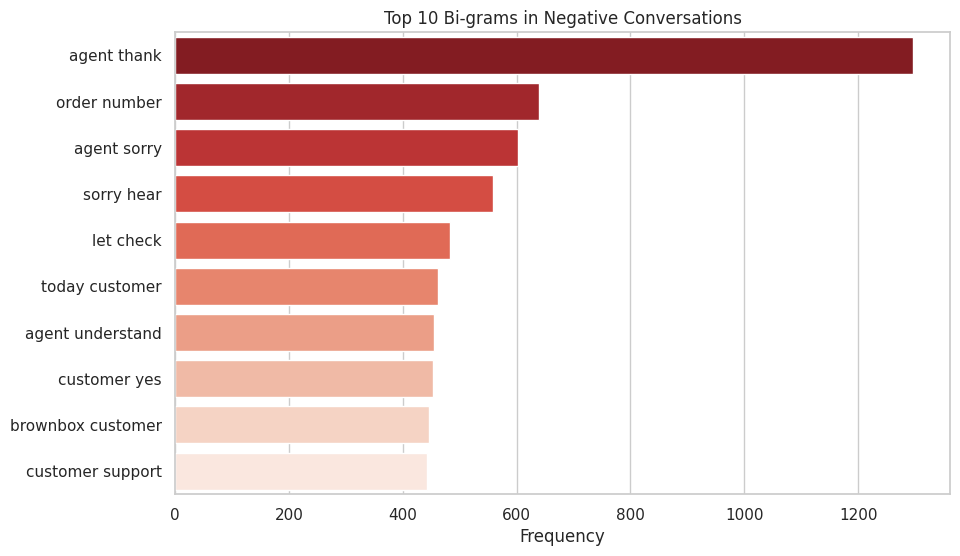

In [10]:
def get_top_ngrams(corpus, n=2, top_k=10):
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    return sorted(words_freq, key=lambda x: x[1], reverse=True)[:top_k]

# Focus on Negative Sentiment patterns
neg_conversations = df[df['customer_sentiment'] == 'negative']['conversation']
top_bigrams = get_top_ngrams(neg_conversations, n=2)
words, counts = zip(*top_bigrams)

plt.figure(figsize=(10, 6))
sns.barplot(x=list(counts), y=list(words), palette='Reds_r')
plt.title('Top 10 Bi-grams in Negative Conversations')
plt.xlabel('Frequency')
plt.show()

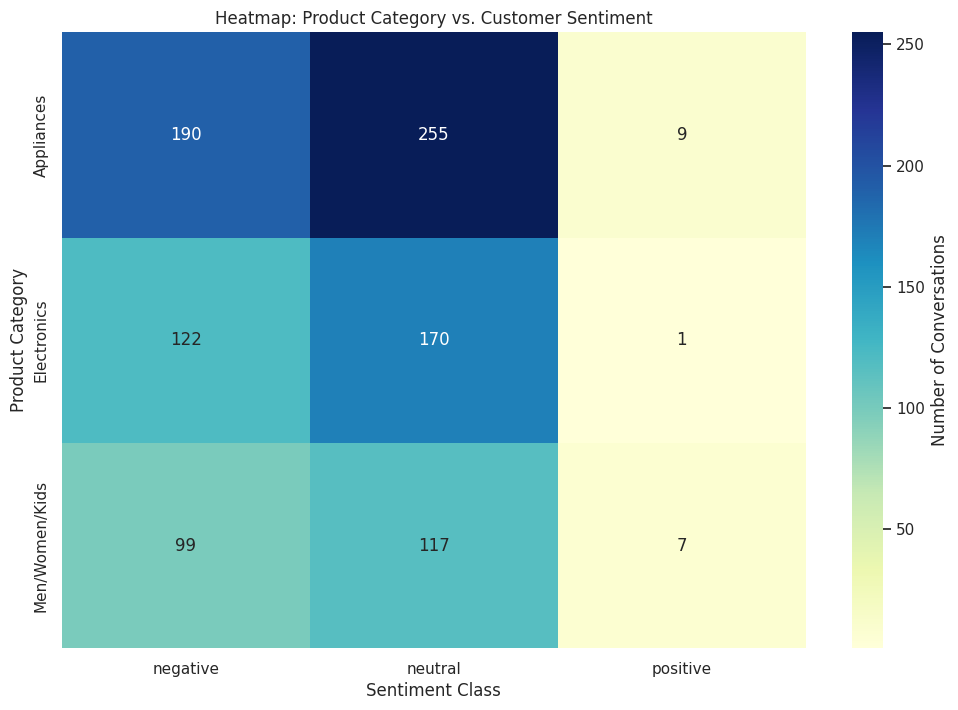

In [11]:
# Create a cross-tabulation of Product Category and Sentiment
heatmap_data = pd.crosstab(df['product_category'], df['customer_sentiment'])

# Plotting the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="YlGnBu", cbar_kws={'label': 'Number of Conversations'})
plt.title('Heatmap: Product Category vs. Customer Sentiment')
plt.ylabel('Product Category')
plt.xlabel('Sentiment Class')
plt.show()

****Section 2:** Data preprocessing**

In [12]:
#Data Cleaning and Normalization

import re
import pandas as pd
from sklearn.preprocessing import LabelEncoder

def clean_support_dialogue(text):

    # PII Removal (Phone and e-mail removal)
    text = re.sub(r'\S+@\S+', '[EMAIL]', text)
    text = re.sub(r'\+?\d[\d -]{8,}\d', '[PHONE]', text)

    # Normalize Speaker Labels (Dialogue Awareness)
    text = text.replace("Customer:", "[USER]").replace("Agent:", "[AGENT]")

    # remove extra spaces and newlines
    text = " ".join(text.split())
    return text

# Apply cleaning
df['cleaned_text'] = df['conversation'].apply(clean_support_dialogue)

# Map target labels -> Negative: 0, Neutral: 1, Positive: 2
sentiment_map = {'negative': 0, 'neutral': 1, 'positive': 2}
df['label'] = df['customer_sentiment'].map(sentiment_map)

print("Text cleaning and label mapping complete.")
print(df[['cleaned_text', 'label']].head(2))

Text cleaning and label mapping complete.
                                        cleaned_text  label
0  [AGENT] Thank you for calling BrownBox Custome...      1
1  [AGENT] Thank you for calling BrownBox custome...      1


In [13]:
# Splitting and Tokenization

from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer
from datasets import Dataset

# Stratified Splitting
train_df, val_df = train_test_split(
    df,
    test_size=0.15,
    random_state=42,
    stratify=df['label'] # Ensures 'positive' class is in both sets
)

# Initialize DeBERTa-v3-small Tokenizer
model_ckpt = "microsoft/deberta-v3-small"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

def tokenize_conversations(batch):
    # Using 512 length
    return tokenizer(
        batch["cleaned_text"],
        truncation=True,
        padding="max_length",
        max_length=512
    )

# Convert to Hugging Face Datasets for high-performance training
train_dataset = Dataset.from_pandas(train_df[['cleaned_text', 'label']])
val_dataset = Dataset.from_pandas(val_df[['cleaned_text', 'label']])

# Map the tokenization across the datasets
train_dataset = train_dataset.map(tokenize_conversations, batched=True)
val_dataset = val_dataset.map(tokenize_conversations, batched=True)

# Remove the text column
train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])
val_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])

print(f"Tokenization complete.")
print(f"Training samples: {len(train_dataset)} | Validation samples: {len(val_dataset)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/578 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

Map:   0%|          | 0/824 [00:00<?, ? examples/s]

Map:   0%|          | 0/146 [00:00<?, ? examples/s]

Tokenization complete.
Training samples: 824 | Validation samples: 146


**Section 3:** Train with Debertav3 Small Model

*   Run 1: Debertav3 Small Baseline Model
*   Run 2: Debertav3 Small Baseline Model + Pre-trained Weights
*   Run 3: Debertav3 Small Baseline Model + Minority Class Augmentation
*   Run 4: Debertav3 Small Baseline Model + Weighted Loss
*   Run 5: All

In [14]:
import wandb
import numpy as np
from sklearn.metrics import accuracy_score, f1_score
from transformers import TrainingArguments, Trainer, AutoModelForSequenceClassification, DataCollatorWithPadding

# Wandb Initialization
wandb.init(
    project="Transformer-Customer-Sentiment",
    name="deberta-v3-small-baseline",
    notes="Baseline fine-tuning for DI 725 Assignment",
    reinit=True
)

# Evaluation Metrics
def compute_metrics(pred):

    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    # Weighted F1 to account for class imbalance
    f1 = f1_score(labels, preds, average="weighted")
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "f1": f1
    }

# Data Collector
# This ensures that all sequences in a batch are padded to the same length
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Run 1

In [15]:
from transformers import AutoConfig, AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback
import wandb

# 1. Initialize WANDB for Run 1
wandb.init(
    project="Transformer-Customer-Sentiment",
    name="Run1",
    notes="Training with no pre-training with 50 epochs and early stopping.",
    reinit=True
)

# 2. Load Configuration (Architecture only, NO pre-trained weights)
config = AutoConfig.from_pretrained("microsoft/deberta-v3-small", num_labels=3)
model_scratch = AutoModelForSequenceClassification.from_config(config)

# 3. Training Arguments
training_args = TrainingArguments(
    output_dir="./results_scratch",
    num_train_epochs=50,
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="wandb",
    fp16=True,
    logging_steps=10
)

# 4. Initialize Trainer with EarlyStoppingCallback
trainer = Trainer(
    model=model_scratch,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)] # Stop if no improvement for 5 epochs
)

# 5. Execute Training
trainer.train()

# Finish the WANDB run
wandb.finish()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.694445,0.624033,0.787671,0.781740
2,0.397835,0.768307,0.753425,0.742858
3,0.292558,0.533131,0.808219,0.802833
4,0.336972,0.571114,0.828767,0.823431
5,0.380381,0.647610,0.842466,0.832368
6,0.221222,0.461089,0.883562,0.876937
7,0.220808,0.730129,0.849315,0.843617
8,0.072199,0.714812,0.842466,0.836982
9,0.233476,0.710857,0.835616,0.833241
10,0.152697,0.673166,0.856164,0.851584


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

eval/accuracy,▃▁▄▅▆█▆▆▅▇▇
eval/f1,▃▁▄▅▆█▆▆▆▇▇
eval/loss,▅█▃▄▅▁▇▇▇▆▇
eval/runtime,█▆▆▇▇▇▇█▇▁█
eval/samples_per_second,▁▃▃▂▂▂▂▁▂█▁
eval/steps_per_second,▁▃▃▂▂▂▂▁▂█▁
train/epoch,▁▁▂▂▂▂▂▂▂▃▃▃▃▃▃▄▄▅▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇███
train/global_step,▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
train/grad_norm,▂▁▂▂▁▅▃▅▃▃▃▁▂▇▁▁▁▄▁▃▁▂▁▂▁▂▇▁█▂▁▃▁▁▆▁▂█▁
train/learning_rate,███▇▇▇▇▆▆▆▅▅▅▅▅▅▅▅▄▄▄▄▄▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▁
+1,...


Map:   0%|          | 0/30 [00:00<?, ? examples/s]

🚀 Running inference and calculating metrics...



--- Test Metrics ---
Accuracy: 0.5333
Weighted F1: 0.4444

Classification Report:
               precision    recall  f1-score   support

    negative       0.80      0.80      0.80        10
     neutral       0.40      0.80      0.53        10
    positive       0.00      0.00      0.00        10

    accuracy                           0.53        30
   macro avg       0.40      0.53      0.44        30
weighted avg       0.40      0.53      0.44        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Results saved to predictions_run1.csv

--- Prediction Distribution ---
predicted_sentiment
neutral     20
negative    10
Name: count, dtype: int64


test/accuracy,▁
test/f1,▁
test/loss,▁
test/runtime,▁
test/samples_per_second,▁
test/steps_per_second,▁
test_accuracy,▁
test_f1,▁
test/accuracy,0.53333
test/f1,0.44444
test/loss,1.5982


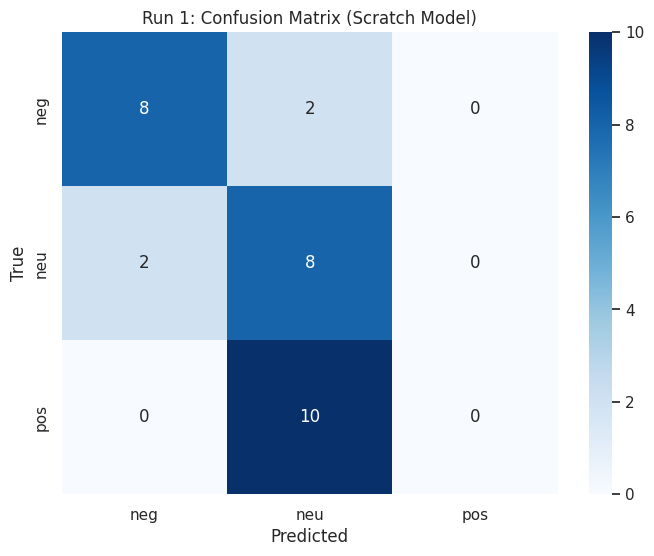

In [19]:
import torch
import pandas as pd
import numpy as np
from datasets import Dataset
import wandb
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Initialize WANDB for Inference
wandb.init(
    project="Transformer-Customer-Sentiment",
    name="Run1_Inference_Metrics",
    job_type="inference",
    reinit=True
)

# 2. Load and Prepare Test Data
test_df = pd.read_csv('test.csv')

# Handle ID column variations
id_col = 'id' if 'id' in test_df.columns else ('ID' if 'ID' in test_df.columns else None)
if id_col is None:
    test_df['id'] = test_df.index
    id_col = 'id'

# 3. Clean and Tokenize
test_df['cleaned_text'] = test_df['conversation'].apply(clean_support_dialogue)

# Check if ground truth labels exist in the test file for metric calculation
has_labels = 'customer_sentiment' in test_df.columns
if has_labels:
    sentiment_map = {'negative': 0, 'neutral': 1, 'positive': 2}
    test_df['label'] = test_df['customer_sentiment'].map(sentiment_map)
    # Include 'label' in the dataset so trainer.predict can calculate metrics
    test_dataset = Dataset.from_pandas(test_df[[id_col, 'cleaned_text', 'label']])
else:
    test_dataset = Dataset.from_pandas(test_df[[id_col, 'cleaned_text']])

test_dataset = test_dataset.map(tokenize_conversations, batched=True)

# 4. Run Prediction
print("🚀 Running inference and calculating metrics...")
output = trainer.predict(test_dataset)

# 5. Extract Predictions and Metrics
preds = np.argmax(output.predictions, axis=-1)
reverse_map = {0: 'negative', 1: 'neutral', 2: 'positive'}
test_df['predicted_sentiment'] = [reverse_map[p] for p in preds]

# 6. Metric Calculation (Only if labels are present)
if has_labels:
    true_labels = test_df['label'].values
    acc = accuracy_score(true_labels, preds)
    f1 = f1_score(true_labels, preds, average='weighted')

    print(f"\n--- Test Metrics ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"Weighted F1: {f1:.4f}")
    print("\nClassification Report:\n", classification_report(true_labels, preds, target_names=['negative', 'neutral', 'positive']))

    # Log metrics to WANDB
    wandb.log({"test_accuracy": acc, "test_f1": f1})

    # Plot Confusion Matrix
    cm = confusion_matrix(true_labels, preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['neg', 'neu', 'pos'], yticklabels=['neg', 'neu', 'pos'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Run 1: Confusion Matrix (Scratch Model)')
    plt.savefig("confusion_matrix_run1.png")

    # Log plot to WANDB
    wandb.log({"confusion_matrix": wandb.Image("confusion_matrix_run1.png")})

# 7. Save and Close
test_df[[id_col, 'predicted_sentiment']].to_csv('predictions_run1.csv', index=False)
print(f"Results saved to predictions_run1.csv")
print("\n--- Prediction Distribution ---")
print(test_df['predicted_sentiment'].value_counts())

wandb.finish()

Run 2

In [21]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback
import wandb

# 1. Initialize WANDB for Run 2
wandb.init(
    project="Transformer-Customer-Sentiment",
    name="Run2_Pretrained",
    notes="Standard transfer learning using pre-trained weights. ",
    reinit=True
)

# 2. Load Model WITH Pre-trained Weights
# This time we use .from_pretrained() instead of .from_config()
model_pretrained = AutoModelForSequenceClassification.from_pretrained(
    "microsoft/deberta-v3-small",
    num_labels=3
)

# 3. Training Arguments
# Identical to Run 1
training_args = TrainingArguments(
    output_dir="./results_run2",
    num_train_epochs=50,
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="wandb",
    fp16=False,
    logging_steps=10
)

# 4. Initialize Trainer
trainer = Trainer(
    model=model_pretrained,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)]
)

# 5. Execute Training
trainer.train()

# Properly close the WANDB session
wandb.finish()

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
classifier.weight                       | MISSING    | 
pooler.dense.weight                     | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier.bias         

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.000000,nan,0.424658,0.253161
2,0.000000,nan,0.424658,0.253161
3,0.000000,nan,0.424658,0.253161
4,0.000000,nan,0.424658,0.253161
5,0.000000,nan,0.424658,0.253161
6,0.000000,nan,0.424658,0.253161


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['deberta.embeddings.LayerNorm.weight', 'deberta.embeddings.LayerNorm.bias', 'deberta.encoder.layer.0.attention.output.LayerNorm.weight', 'deberta.encoder.layer.0.attention.output.LayerNorm.bias', 'deberta.encoder.layer.0.output.LayerNorm.weight', 'deberta.encoder.layer.0.output.LayerNorm.bias', 'deberta.encoder.layer.1.attention.output.LayerNorm.weight', 'deberta.encoder.layer.1.attention.output.LayerNorm.bias', 'deberta.encoder.layer.1.output.LayerNorm.weight', 'deberta.encoder.layer.1.output.LayerNorm.bias', 'deberta.encoder.layer.2.attention.output.LayerNorm.weight', 'deberta.encoder.layer.2.attention.output.LayerNorm.bias', 'deberta.encoder.layer.2.output.LayerNorm.weight', 'deberta.encoder.layer.2.output.LayerNorm.bias', 'deberta.encoder.layer.3.attention.output.LayerNorm.weight', 'deberta.encoder.layer.3.attention.output.LayerNorm.bias', 'deberta.encoder.layer.3.output.LayerNorm.weight', 'deberta.encoder.layer.3.output.Laye

eval/accuracy,▁▁▁▁▁▁
eval/f1,▁▁▁▁▁▁
eval/runtime,▇▄▁▁█▇
eval/samples_per_second,▂▅██▁▂
eval/steps_per_second,▂▅██▁▂
train/epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
train/global_step,▁▁▁▁▁▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
train/grad_norm,▁▁█▁
train/learning_rate,███▇▇▇▇▇▇▆▆▆▆▆▆▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▁▁▁▁
train/loss,█▄▃▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+1,...


No ID column found. Creating 'id' from dataframe index.


Map:   0%|          | 0/30 [00:00<?, ? examples/s]

Running inference for Run 2 (Pre-trained Baseline)...



--- Run 2 (Pre-trained) Metrics ---
Accuracy: 0.3333 | Weighted F1: 0.1667
Predictions saved to predictions_run2_pretrained.csv

--- Prediction Distribution ---
predicted_sentiment
negative    30
Name: count, dtype: int64


run2_test_acc,▁
run2_test_f1,▁
test/accuracy,▁
test/f1,▁
test/runtime,▁
test/samples_per_second,▁
test/steps_per_second,▁
+1,...
run2_test_acc,0.33333
run2_test_f1,0.16667
test/accuracy,0.33333


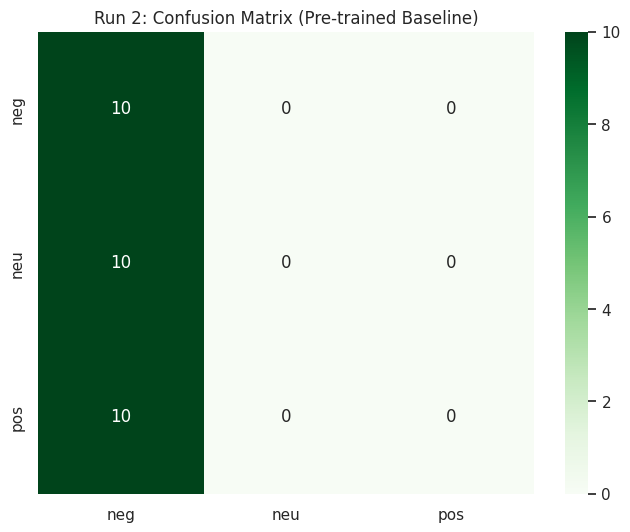

In [25]:
import torch
import pandas as pd
import numpy as np
from datasets import Dataset
import wandb
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize WANDB for Run 2 Inference
wandb.init(
    project="Transformer-Customer-Sentiment",
    name="Run2_Inference_Metrics",
    job_type="inference",
    reinit=True
)

# Load and Prepare Test Data
test_df = pd.read_csv('test.csv')

if 'id' in test_df.columns:
    id_col = 'id'
elif 'ID' in test_df.columns:
    id_col = 'ID'
else:
    print("No ID column found. Creating 'id' from dataframe index.")
    test_df['id'] = test_df.index
    id_col = 'id'

# Apply Text Cleaning
test_df['cleaned_text'] = test_df['conversation'].apply(clean_support_dialogue)

# Handle Ground Truth Labels
has_labels = 'customer_sentiment' in test_df.columns
if has_labels:
    sentiment_map = {'negative': 0, 'neutral': 1, 'positive': 2}
    test_df['label'] = test_df['customer_sentiment'].map(sentiment_map)
    # Include 'label' so the trainer can calculate internal metrics
    test_dataset = Dataset.from_pandas(test_df[[id_col, 'cleaned_text', 'label']])
else:
    test_dataset = Dataset.from_pandas(test_df[[id_col, 'cleaned_text']])

# Tokenization
test_dataset = test_dataset.map(tokenize_conversations, batched=True)

# Run Prediction
print("Running inference for Run 2 (Pre-trained Baseline)...")
output = trainer.predict(test_dataset)

# Map Numerical Predictions back to Labels
preds = np.argmax(output.predictions, axis=-1)
reverse_map = {0: 'negative', 1: 'neutral', 2: 'positive'}
test_df['predicted_sentiment'] = [reverse_map[p] for p in preds]

# Metric Calculation & Scientific Visualization
if has_labels:
    true_labels = test_df['label'].values
    acc = accuracy_score(true_labels, preds)
    f1 = f1_score(true_labels, preds, average='weighted')

    print(f"\n--- Run 2 (Pre-trained) Metrics ---")
    print(f"Accuracy: {acc:.4f} | Weighted F1: {f1:.4f}")

    # Log metrics to WANDB for your final comparison table
    wandb.log({"run2_test_acc": acc, "run2_test_f1": f1})

    # Generate Confusion Matrix Visualization
    cm = confusion_matrix(true_labels, preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', # Using Green for Run 2
                xticklabels=['neg', 'neu', 'pos'], yticklabels=['neg', 'neu', 'pos'])
    plt.title('Run 2: Confusion Matrix (Pre-trained Baseline)')
    plt.savefig("cm_run2.png")

    # Send the image to WANDB
    wandb.log({"confusion_matrix_run2": wandb.Image("cm_run2.png")})

# Save CSV for Submission/Comparison
test_df[[id_col, 'predicted_sentiment']].to_csv('predictions_run2_pretrained.csv', index=False)

print(f"Predictions saved to predictions_run2_pretrained.csv")
print("\n--- Prediction Distribution ---")
print(test_df['predicted_sentiment'].value_counts())

# Properly close the WANDB session
wandb.finish()

Run 3

In [26]:
from imblearn.over_sampling import RandomOverSampler
import pandas as pd
from datasets import Dataset

# 1. Initialize the Sampler
# 'minority' will bring the smallest class up to the count of the largest class
ros = RandomOverSampler(random_state=42)

# 2. Resample the training dataframe
X_resampled, y_resampled = ros.fit_resample(
    train_df[['cleaned_text']],
    train_df['label']
)

# 3. Create the New Augmented Training DataFrame
train_df_aug = pd.DataFrame({
    'cleaned_text': X_resampled['cleaned_text'],
    'label': y_resampled
})

# 4. Convert back to Hugging Face Dataset and Tokenize
train_dataset_aug = Dataset.from_pandas(train_df_aug)
train_dataset_aug = train_dataset_aug.map(tokenize_conversations, batched=True)

print(f"Original Training Size: {len(train_df)}")
print(f"Augmented Training Size: {len(train_df_aug)}")
print("\n--- New Label Distribution ---")
print(train_df_aug['label'].value_counts())

Map:   0%|          | 0/1380 [00:00<?, ? examples/s]

Original Training Size: 824
Augmented Training Size: 1380

--- New Label Distribution ---
label
1    460
0    460
2    460
Name: count, dtype: int64


In [27]:
import wandb

# 1. Initialize WANDB for Run 3
wandb.init(
    project="Transformer-Customer-Sentiment",
    name="Run3_Oversampling",
    notes="Run 3: Addressing imbalance via Random Over-Sampling on training data.",
    reinit=True
)

# 2. Load Pre-trained Model
model_aug = AutoModelForSequenceClassification.from_pretrained(
    "microsoft/deberta-v3-small",
    num_labels=3
)

# 3. Training Arguments
training_args_aug = TrainingArguments(
    output_dir="./results_run3",
    num_train_epochs=50,
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="wandb",
    fp16=False,
    logging_steps=10
)

# 4. Initialize Trainer with the AUGMENTED dataset
trainer = Trainer(
    model=model_aug,
    args=training_args_aug,
    train_dataset=train_dataset_aug, # Using resampled data
    eval_dataset=val_dataset,       # Keeping original validation data
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)]
)

# 5. Train
trainer.train()
wandb.finish()

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
classifier.weight                       | MISSING    | 
pooler.dense.weight                     | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier.bias         

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.000000,nan,0.424658,0.253161
2,0.000000,nan,0.424658,0.253161
3,0.000000,nan,0.424658,0.253161
4,0.000000,nan,0.424658,0.253161
5,0.000000,nan,0.424658,0.253161
6,0.000000,nan,0.424658,0.253161


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['deberta.embeddings.LayerNorm.weight', 'deberta.embeddings.LayerNorm.bias', 'deberta.encoder.layer.0.attention.output.LayerNorm.weight', 'deberta.encoder.layer.0.attention.output.LayerNorm.bias', 'deberta.encoder.layer.0.output.LayerNorm.weight', 'deberta.encoder.layer.0.output.LayerNorm.bias', 'deberta.encoder.layer.1.attention.output.LayerNorm.weight', 'deberta.encoder.layer.1.attention.output.LayerNorm.bias', 'deberta.encoder.layer.1.output.LayerNorm.weight', 'deberta.encoder.layer.1.output.LayerNorm.bias', 'deberta.encoder.layer.2.attention.output.LayerNorm.weight', 'deberta.encoder.layer.2.attention.output.LayerNorm.bias', 'deberta.encoder.layer.2.output.LayerNorm.weight', 'deberta.encoder.layer.2.output.LayerNorm.bias', 'deberta.encoder.layer.3.attention.output.LayerNorm.weight', 'deberta.encoder.layer.3.attention.output.LayerNorm.bias', 'deberta.encoder.layer.3.output.LayerNorm.weight', 'deberta.encoder.layer.3.output.Laye

eval/accuracy,▁▁▁▁▁▁
eval/f1,▁▁▁▁▁▁
eval/runtime,▂▅█▁▅▅
eval/samples_per_second,▆▄▁█▄▃
eval/steps_per_second,▇▄▁█▄▃
train/epoch,▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇██
train/global_step,▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▇▇▇▇▇▇█████
train/grad_norm,█▁
train/learning_rate,████▇▇▇▇▇▇▇▆▆▆▆▅▅▅▅▅▅▅▄▄▄▄▄▃▃▃▃▂▂▂▂▂▂▂▁▁
train/loss,█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+1,...


⚠️ No ID column found. Creating 'id' from index.


Map:   0%|          | 0/30 [00:00<?, ? examples/s]

 Running inference for Run 3 (Oversampled Model)...



--- Run 3 Metrics ---
Accuracy: 0.3333 | Weighted F1: 0.1667
Results saved to predictions_run3_aug.csv

--- Prediction Distribution ---
predicted_sentiment
negative    30
Name: count, dtype: int64


run3_test_acc,▁
run3_test_f1,▁
test/accuracy,▁
test/f1,▁
test/runtime,▁
test/samples_per_second,▁
test/steps_per_second,▁
+1,...
run3_test_acc,0.33333
run3_test_f1,0.16667
test/accuracy,0.33333


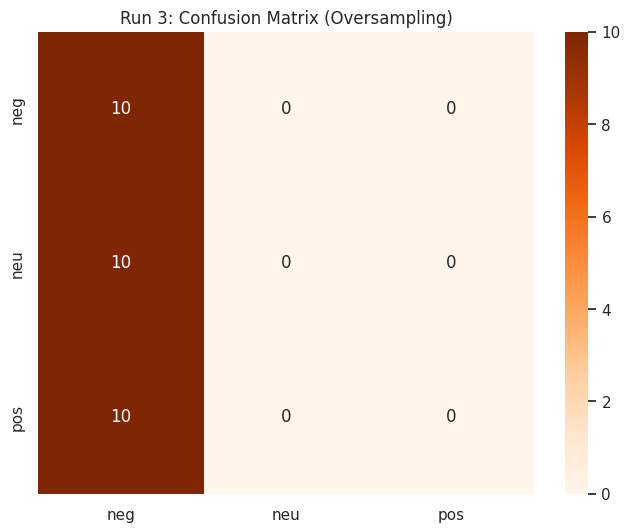

In [28]:
import torch
import pandas as pd
import numpy as np
from datasets import Dataset
import wandb
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Initialize WANDB for Run 3 Inference
wandb.init(
    project="Transformer-Customer-Sentiment",
    name="Run3_Inference_Metrics",
    job_type="inference",
    reinit=True
)

# 2. Load and Prepare Test Data
test_df = pd.read_csv('test.csv')

# --- Robust ID Handling ---
if 'id' in test_df.columns:
    id_col = 'id'
elif 'ID' in test_df.columns:
    id_col = 'ID'
else:
    print("⚠️ No ID column found. Creating 'id' from index.")
    test_df['id'] = test_df.index
    id_col = 'id'

# 3. Clean and Tokenize (Step 6 Logic)
test_df['cleaned_text'] = test_df['conversation'].apply(clean_support_dialogue)

# 4. Handle Labels for Metric Calculation
has_labels = 'customer_sentiment' in test_df.columns
if has_labels:
    sentiment_map = {'negative': 0, 'neutral': 1, 'positive': 2}
    test_df['label'] = test_df['customer_sentiment'].map(sentiment_map)
    test_dataset = Dataset.from_pandas(test_df[[id_col, 'cleaned_text', 'label']])
else:
    test_dataset = Dataset.from_pandas(test_df[[id_col, 'cleaned_text']])

test_dataset = test_dataset.map(tokenize_conversations, batched=True)

# 5. Run Prediction
# Trainer currently holds the Run 3 (Oversampled) model weights
print(" Running inference for Run 3 (Oversampled Model)...")
output = trainer.predict(test_dataset)

# 6. Map to Sentiment Labels
preds = np.argmax(output.predictions, axis=-1)
reverse_map = {0: 'negative', 1: 'neutral', 2: 'positive'}
test_df['predicted_sentiment'] = [reverse_map[p] for p in preds]

# 7. Metric Calculation & Visualization
if has_labels:
    true_labels = test_df['label'].values
    acc = accuracy_score(true_labels, preds)
    f1 = f1_score(true_labels, preds, average='weighted')

    print(f"\n--- Run 3 Metrics ---")
    print(f"Accuracy: {acc:.4f} | Weighted F1: {f1:.4f}")

    # Log to WANDB
    wandb.log({"run3_test_acc": acc, "run3_test_f1": f1})

    # Generate Confusion Matrix
    cm = confusion_matrix(true_labels, preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
                xticklabels=['neg', 'neu', 'pos'], yticklabels=['neg', 'neu', 'pos'])
    plt.title('Run 3: Confusion Matrix (Oversampling)')
    plt.savefig("cm_run3.png")

    # Log image to WANDB
    wandb.log({"confusion_matrix_run3": wandb.Image("cm_run3.png")})

# 8. Save CSV for Comparison
test_df[[id_col, 'predicted_sentiment']].to_csv('predictions_run3_aug.csv', index=False)

print(f"Results saved to predictions_run3_aug.csv")
print("\n--- Prediction Distribution ---")
print(test_df['predicted_sentiment'].value_counts())

wandb.finish()